In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare_dataset (1).csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [17]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [18]:
df.shape

(55500, 15)

In [19]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [20]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [21]:
df = df.dropna()

In [22]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], utc=True)
df['Date of Admission'].dtype

datetime64[ns, UTC]

In [23]:
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], utc=True)
df['Discharge Date'].dtype

datetime64[ns, UTC]

In [24]:
df["Hospital_Stays"] = df["Discharge Date"] - df["Date of Admission"]
df['Hospital_Stays'] = df['Hospital_Stays'].dt.days
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Hospital_Stays
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31 00:00:00+00:00,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02 00:00:00+00:00,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20 00:00:00+00:00,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26 00:00:00+00:00,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22 00:00:00+00:00,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07 00:00:00+00:00,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18 00:00:00+00:00,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18 00:00:00+00:00,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19 00:00:00+00:00,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09 00:00:00+00:00,Penicillin,Abnormal,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16 00:00:00+00:00,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15 00:00:00+00:00,Penicillin,Abnormal,30
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23 00:00:00+00:00,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01 00:00:00+00:00,Aspirin,Normal,9
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13 00:00:00+00:00,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10 00:00:00+00:00,Ibuprofen,Abnormal,28
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25 00:00:00+00:00,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31 00:00:00+00:00,Ibuprofen,Abnormal,6


In [25]:
billing = df.groupby(["Medical Condition", "Insurance Provider"])["Billing Amount"].sum().unstack()
billing

Insurance Provider,Aetna,Blue Cross,Cigna,Medicare,UnitedHealthcare
Medical Condition,,,,,
Arthritis,4.667744e+07,4.776824e+07,4.810453e+07,4.677861e+07,4.800029e+07
Asthma,4.497371e+07,4.613516e+07,4.883917e+07,4.722901e+07,4.828272e+07
Cancer,4.533568e+07,4.538242e+07,4.768493e+07,4.728065e+07,4.648417e+07
Diabetes,4.709108e+07,4.802529e+07,4.855774e+07,4.885277e+07,4.601285e+07
Hypertension,4.858130e+07,4.658659e+07,4.527089e+07,4.767472e+07,4.760715e+07
Obesity,4.620389e+07,4.935658e+07,4.868209e+07,4.790500e+07,4.606736e+07


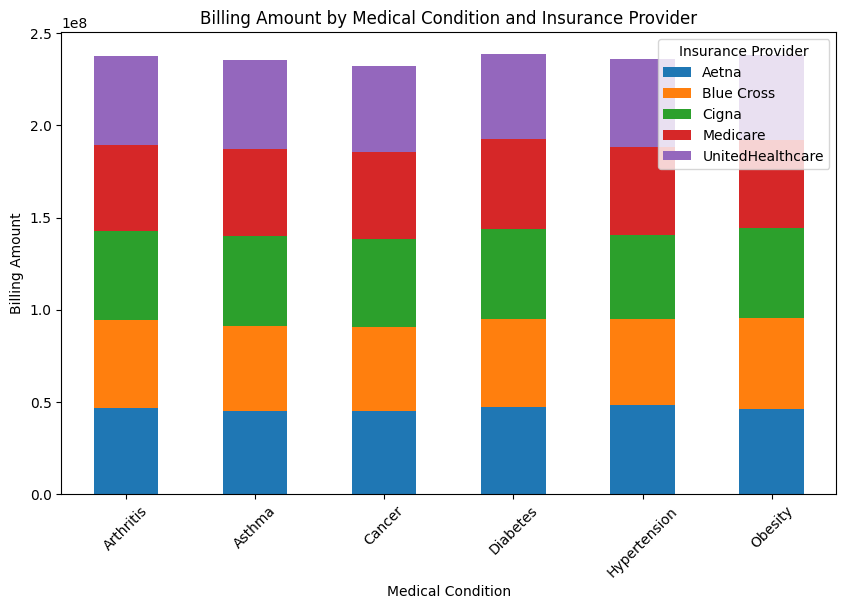

In [26]:
billing.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.show()

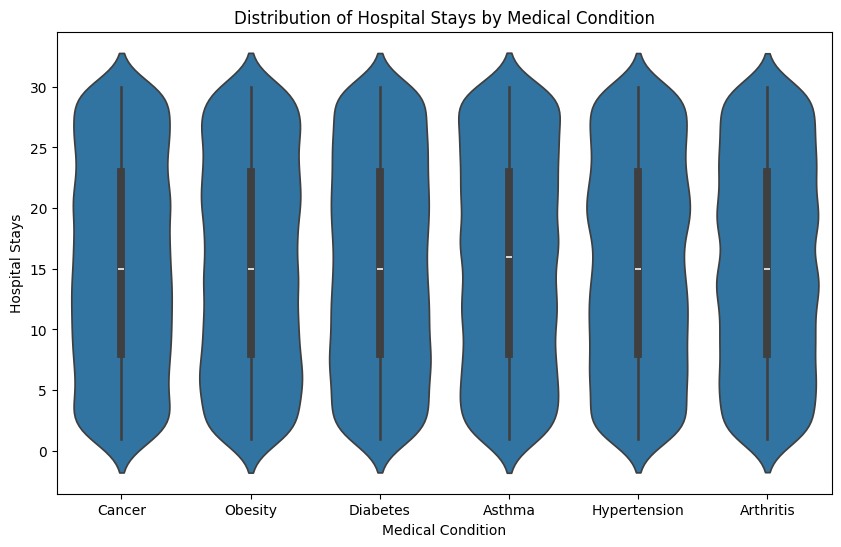

In [27]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Medical Condition",
    y="Hospital_Stays",
    data=df,
)
plt.title("Distribution of Hospital Stays by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Hospital Stays")
plt.show()

In [32]:
df['Admission Month'] = df['Date of Admission'].dt.to_period('M')
df['Admission Month']

/tmp/ipykernel_4682/1678956926.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Admission Month'] = df['Date of Admission'].dt.to_period('M')


,Admission Month
0,2024-01
1,2019-08
2,2022-09
3,2020-11
4,2022-09
...,...
55495,2020-08
55496,2020-01
55497,2020-07
55498,2019-05


In [33]:
monthly_admissions = df.groupby('Admission Month').size()
monthly_admissions

,0
Admission Month,
2019-05,686
2019-06,907
2019-07,957
2019-08,1001
2019-09,936
...,...
2024-01,909
2024-02,880
2024-03,906


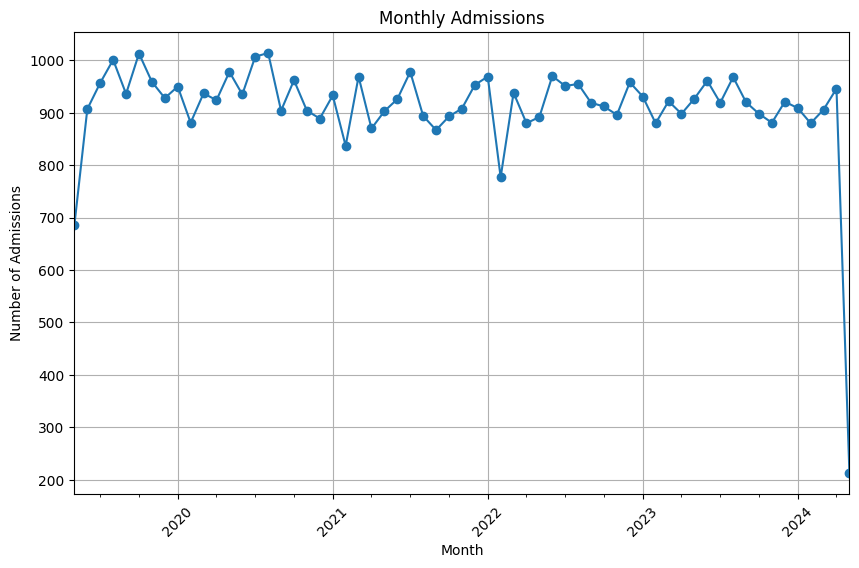

In [35]:
plt.figure(figsize=(10, 6))

monthly_admissions.plot(kind='line', marker='o')
plt.title('Monthly Admissions')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [38]:
correlation_matrix = df[['Age', 'Hospital_Stays', 'Billing Amount']].corr()
correlation_matrix

,Age,Hospital_Stays,Billing Amount
Age,1.000000,0.008220,-0.003832
Hospital_Stays,0.008220,1.000000,-0.005602
Billing Amount,-0.003832,-0.005602,1.000000


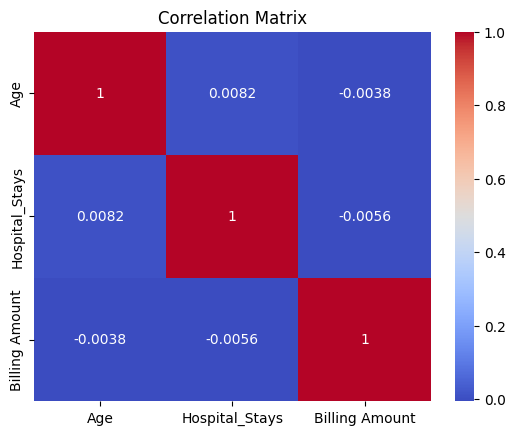

In [39]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Executive Summary — Healthcare Dataset EDA (Week 6)

## Purpose

This analysis was conducted to extract operational and financial insights from a hospital's patient-level records. The objective was to understand how billing costs, length of stay, and admission volume vary across medical conditions, insurance providers, and time — providing a foundation for cost management, capacity planning, and further predictive modeling.

## Scope and Methodology

The analysis followed a standard four-stage EDA (Exploratory Data Analysis) pipeline:

1. **Data Preparation** — Raw patient records were loaded and audited for missing values, which were removed to ensure analytical accuracy. Admission and discharge dates were converted into a proper date format to enable time-based calculations.
2. **Feature Engineering** — Two derived metrics were created: **Length of Stay** (days between admission and discharge) and **Admission Month** (for trend tracking), since neither existed directly in the raw data but were necessary for the questions being asked.
3. **Financial Analysis** — Total billing amounts were broken down by medical condition and insurance provider to identify which condition/insurer combinations drive the highest costs.
4. **Clinical and Temporal Analysis** — Length-of-stay patterns were examined across conditions, admission volumes were tracked month-over-month, and relationships between patient age, stay duration, and billing amount were tested statistically.

## What Each Graph Shows

- **Stacked Bar Chart (Billing by Condition & Insurer):** Shows total billing amount for each medical condition, split into colored segments by insurance provider — makes it easy to see which condition/insurer pairs contribute most to overall costs.
- **Violin Plot (Hospital Stay Distribution):** Shows the full spread of stay lengths for each medical condition, including where most values cluster and how much they vary — not just an average.
- **Line Chart (Monthly Admissions):** Plots the number of patient admissions per month, making it easy to spot upward/downward trends or seasonal patterns over time.
- **Heatmap (Correlation Matrix):** Displays how strongly Age, Hospital Stays, and Billing Amount are related to one another, with values from -1 to +1 and color intensity indicating strength of the relationship.

## Key Areas of Insight

| Analysis | Business Question Answered |
|---|---|
| Billing by Condition & Insurer | Which conditions and insurers are associated with the largest total healthcare spend? |
| Stay Duration Distribution | Which conditions are linked to longer or more unpredictable hospital stays? |
| Monthly Admissions Trend | Is patient volume growing, shrinking, or seasonal? |
| Correlation Analysis (Age, Stay, Billing) | Do older patients or longer stays correspond to higher billing amounts? |